In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict, Any, List
import itertools

# Reproducible RNG for the experiment generator (not ESN internals)
GLOBAL_RNG = np.random.default_rng(7)

In [2]:
@dataclass
class ESNConfig:
    n_reservoir: int = 150          # reservoir size
    input_scaling: float = 0.5      # scale of W_in
    spectral_radius: float = 0.9    # ρ(W)
    leak_rate: float = 1.0          # 1.0: vanilla, <1: leaky-integrator
    sparsity: float = 0.9           # fraction of zeros in W
    bias: float = 0.0
    ridge: float = 1e-5             # ridge for readout
    activation: str = "tanh"        # "tanh" or "relu"
    seed: int = 11                  # ESN’s own RNG seed

class ESN:
    def __init__(self, cfg: ESNConfig):
        self.cfg = cfg
        self.rng = np.random.default_rng(cfg.seed)

        # Input weights (N x 1) for scalar input
        self.W_in = self.rng.standard_normal((cfg.n_reservoir, 1)) * cfg.input_scaling

        # Sparse reservoir matrix W then scaled to the target spectral radius
        N = cfg.n_reservoir
        W = self.rng.standard_normal((N, N))
        mask = self.rng.random((N, N)) < cfg.sparsity
        W[mask] = 0.0

        eigvals = np.linalg.eigvals(W)
        sr = float(np.max(np.abs(eigvals))) if np.max(np.abs(eigvals)) > 0 else 1.0
        W *= (cfg.spectral_radius / sr)
        self.W = W

        self.b = np.full((N, 1), cfg.bias)

    def _act(self, x):
        if self.cfg.activation == "tanh":
            return np.tanh(x)
        elif self.cfg.activation == "relu":
            return np.maximum(0.0, x)
        else:
            raise ValueError("activation must be 'tanh' or 'relu'")

    def run(self, u: np.ndarray, washout: int = 300) -> Tuple[np.ndarray, np.ndarray]:
        """
        Drive the reservoir with scalar input u (shape: (T,))
        Returns:
          X_eff: states after washout, shape (T-washout, N)
          U_eff: inputs aligned with X_eff, shape (T-washout,)
        """
        u = u.reshape(-1, 1)
        N = self.cfg.n_reservoir
        T = u.shape[0]

        x = np.zeros((N, 1))
        X = np.zeros((T, N))

        alpha = self.cfg.leak_rate
        for t in range(T):
            pre = self.W @ x + self.W_in @ u[t:t+1] + self.b
            x_new = self._act(pre)
            x = (1 - alpha) * x + alpha * x_new if alpha < 1.0 else x_new
            X[t] = x.ravel()

        return X[washout:], u[washout:].ravel()


def _ridge_readout(X: np.ndarray, y: np.ndarray, ridge: float) -> np.ndarray:
    """Solve w = (X^T X + λI)^-1 X^T y."""
    XT = X.T
    A = XT @ X + ridge * np.eye(X.shape[1])
    b = XT @ y
    return np.linalg.solve(A, b)


def mc_for_delay(X: np.ndarray, u: np.ndarray, tau: int, ridge: float, split: float = 0.7) -> float:
    """
    Memory capacity at delay τ:
      1) target y_t = u_{t-τ}
      2) train linear readout (ridge) on first split% of samples
      3) MC(τ) = corr^2(y_hat, y) on the test split
    """
    T = len(u)
    if tau >= T - 1:
        return 0.0

    # Align target with states
    y = u[:-tau] if tau > 0 else u.copy()
    X_aligned = X[tau:]  # same length as y

    n_train = int(len(y) * split)
    if n_train < 5 or len(y) - n_train < 5:
        return 0.0

    X_tr, y_tr = X_aligned[:n_train], y[:n_train]
    X_te, y_te = X_aligned[n_train:], y[n_train:]

    w = _ridge_readout(X_tr, y_tr, ridge)
    y_hat = X_te @ w

    # squared correlation
    y_te_  = y_te  - y_te.mean()
    y_hat_ = y_hat - y_hat.mean()
    denom = (np.sqrt((y_te_**2).sum()) * np.sqrt((y_hat_**2).sum()))
    if denom == 0:
        return 0.0
    r = (y_te_ @ y_hat_) / denom
    return float(r**2)


def memory_capacity_curve(u: np.ndarray, cfg: ESNConfig,
                          tau_max: int = 100, washout: int = 300) -> Tuple[np.ndarray, float]:
    """Return MC(τ) for τ=1..tau_max and Total MC (sum)."""
    esn = ESN(cfg)
    X, u_eff = esn.run(u, washout=washout)
    mcs = [mc_for_delay(X, u_eff, tau, ridge=cfg.ridge, split=0.7) for tau in range(1, tau_max+1)]
    return np.array(mcs), float(np.sum(mcs))


def generate_mc_input(T: int, seed: int = 0) -> np.ndarray:
    """i.i.d. noise in [-0.5, 0.5] — standard for MC tests."""
    rng = np.random.default_rng(seed)
    return rng.uniform(-0.5, 0.5, size=T)


def sweep_params(base_cfg: ESNConfig,
                 u: np.ndarray,
                 tau_max: int,
                 washout: int,
                 grid: Dict[str, List[Any]]) -> List[Dict[str, Any]]:
    """
    Sweep a parameter grid. Each result dict has the params, MC curve, total MC, and n_reservoir.
    """
    keys = list(grid.keys())
    combos = list(itertools.product(*[grid[k] for k in keys]))
    results = []
    for combo in combos:
        cfg_kwargs = base_cfg.__dict__.copy()
        for k, v in zip(keys, combo):
            cfg_kwargs[k] = v
        cfg = ESNConfig(**cfg_kwargs)
        mc_curve, mc_total = memory_capacity_curve(u, cfg, tau_max=tau_max, washout=washout)
        rec = {k: v for k, v in zip(keys, combo)}
        rec["mc_curve"] = mc_curve
        rec["total_mc"] = mc_total
        rec["n_reservoir"] = cfg.n_reservoir
        results.append(rec)
    return results


Total MC = 20.108  (upper bound ≲ n_reservoir = 150)


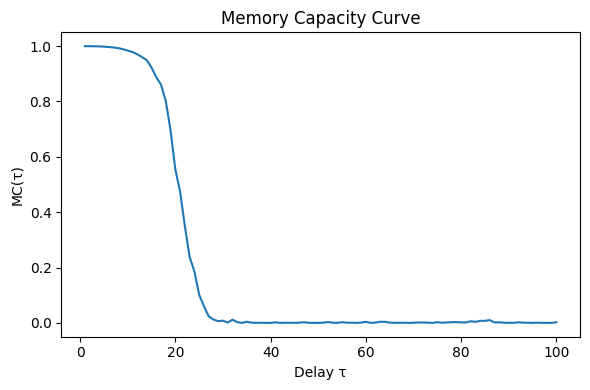

In [3]:
# Cell 3: single ESN run — MC(τ) curve and sum
T_total = 3000     # keep modest for quick execution
washout = 300
tau_max = 100

u = generate_mc_input(T_total, seed=7)

cfg = ESNConfig(
    n_reservoir=150, input_scaling=0.5, spectral_radius=0.9,
    leak_rate=1.0, sparsity=0.9, bias=0.0, ridge=1e-5, activation="tanh", seed=11
)

mc_curve, total_mc = memory_capacity_curve(u, cfg, tau_max=tau_max, washout=washout)
print(f"Total MC = {total_mc:.3f}  (upper bound ≲ n_reservoir = {cfg.n_reservoir})")

# Plot MC(τ)
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, tau_max+1), mc_curve)
plt.xlabel("Delay τ")
plt.ylabel("MC(τ)")
plt.title("Memory Capacity Curve")
plt.tight_layout()
plt.show()


In [14]:
# Cell 4: sweep ONE parameter grid at a time to keep runtime fast

# Base config
base = ESNConfig(
    n_reservoir=150, input_scaling=0.5, spectral_radius=0.9,
    leak_rate=1.0, sparsity=0.9, bias=0.0, ridge=1e-5, activation="tanh", seed=11
)

# Time settings
T_total = 3000
washout = 300
tau_max = 100
u = generate_mc_input(T_total, seed=7)

# ---- Pick ONE grid below (comment others) ----

# A) Spectral radius sweep
# grid = {"spectral_radius": [0.2, 0.5, 0.9, 1.1, 1.4]}

# B) Input scaling sweep
# grid = {"input_scaling": [0.1, 0.5, 1.0]}

# C) Leak rate sweep
# grid = {"leak_rate": [0.3, 0.6, 1.0]}

# D) Reservoir size sweep
grid = {"n_reservoir": [100, 200, 400, 700, 1000]}

# E) Sparsity sweep
# grid = {"sparsity": [0.7, 0.9, 0.97]}

# ----------------------------------------------

results = sweep_params(base, u, tau_max=tau_max, washout=washout, grid=grid)

# Results table
rows = []
for r in results:
    row = {k: r[k] for k in grid.keys()}
    row["n_reservoir"] = r["n_reservoir"]
    row["total_mc"] = r["total_mc"]
    rows.append(row)

df = pd.DataFrame(rows).sort_values("total_mc", ascending=False).reset_index(drop=True)
df


,n_reservoir,total_mc
0,1000,26.740160
1,700,25.621320
2,400,25.060035
3,200,21.085130
4,100,16.361706


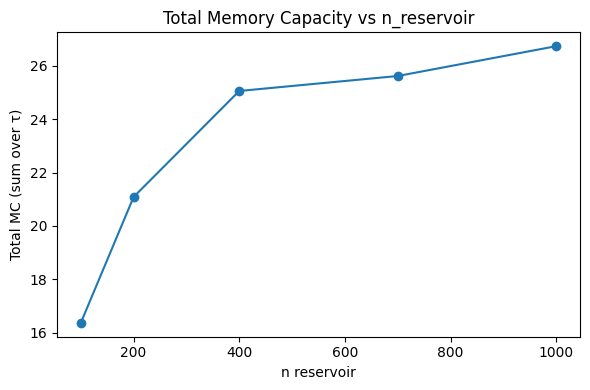

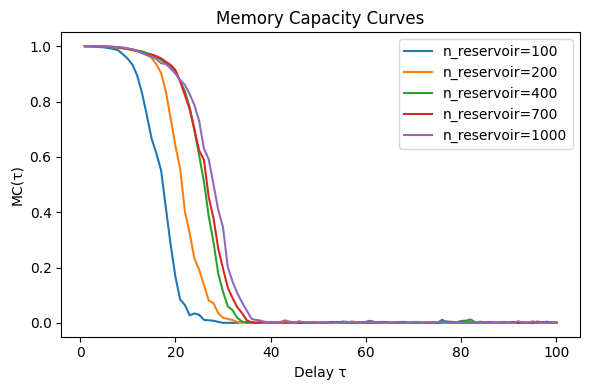

In [15]:
# Cell 5: visualize sweep (assumes you swept a single parameter)
key = list(grid.keys())[0]
xs = [r[key] for r in results]
ys = [r["total_mc"] for r in results]

plt.figure(figsize=(6,4))
plt.plot(xs, ys, marker="o")
plt.xlabel(key.replace("_", " "))
plt.ylabel("Total MC (sum over τ)")
plt.title(f"Total Memory Capacity vs {key}")
plt.tight_layout()
plt.show()

# MC(τ) curves (first up to 5 settings to avoid clutter)
plt.figure(figsize=(6,4))
for r in results[:5]:
    label = ", ".join([f"{k}={r[k]}" for k in grid.keys()])
    plt.plot(np.arange(1, tau_max+1), r["mc_curve"], label=label)
plt.xlabel("Delay τ")
plt.ylabel("MC(τ)")
plt.title("Memory Capacity Curves")
plt.legend()
plt.tight_layout()
plt.show()
